Reading Data

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Data Exploration

In [4]:
df.shape
df.info()
df.describe()
df.dtypes.value_counts()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

np.int64(31994)

In [5]:
cols = [
    "hotel",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type",
    "agent",
    "company",
    "reservation_status"
]
for col in cols:
    print(f"{col}: {df[col].nunique()} unique values")

hotel: 2 unique values
meal: 5 unique values
country: 177 unique values
market_segment: 8 unique values
distribution_channel: 5 unique values
reserved_room_type: 10 unique values
assigned_room_type: 12 unique values
deposit_type: 3 unique values
customer_type: 4 unique values
agent: 333 unique values
company: 352 unique values
reservation_status: 3 unique values


Handling Douplicates

In [6]:

df_clean = df.copy()
df_clean.drop_duplicates(inplace=True)

Handling Negative Values

In [7]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    count = (df[col] < 0).sum()

    if count > 0:
        print(f"{col}: {count} negative values")

df_clean = df_clean[df_clean['adr'] >= 0]

adr: 1 negative values


In [8]:

df_clean.drop(['reservation_status', 'reservation_status_date', 'company','agent'], axis=1, inplace=True)

Handlig missing Values

In [9]:

df_clean = df_clean.dropna(subset=['children'])


df_clean['country'] = df_clean['country'].fillna('Unknown')


df_clean.shape

(87391, 28)

In [10]:

outlier_cols = ['lead_time', 'adr', 'adults', 'children', 'booking_changes']

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

In [11]:
df_clean.shape

(87391, 28)

In [12]:
X= df_clean.drop("is_canceled", axis=1)
y= df_clean["is_canceled"]
cols = [
     "hotel",
     "arrival_date_month",
     "meal",
     "market_segment",
     "distribution_channel",
     "reserved_room_type",
     "assigned_room_type",
     "deposit_type",
     "customer_type"
]
X= pd.get_dummies(
     X,
     columns=cols,
     drop_first=True
 )

le_country = LabelEncoder()
X["country"] = le_country.fit_transform(X["country"])

In [13]:
# Create readable labels for cancellation status

df_clean["booking_status"] = df_clean["is_canceled"].map({
    0: "Not Canceled",
    1: "Canceled"
})

df_clean["booking_status"].value_counts()

booking_status
Not Canceled    63370
Canceled        24021
Name: count, dtype: int64

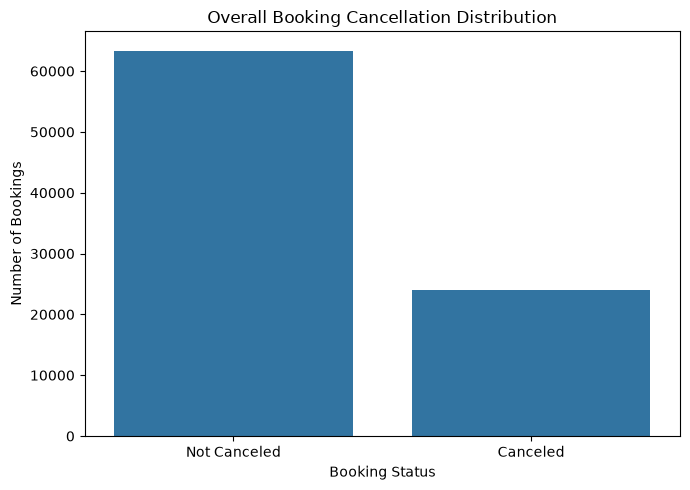

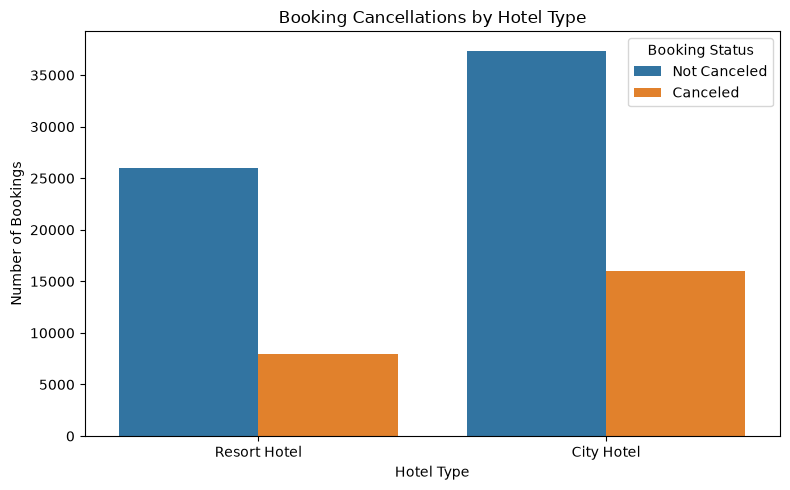

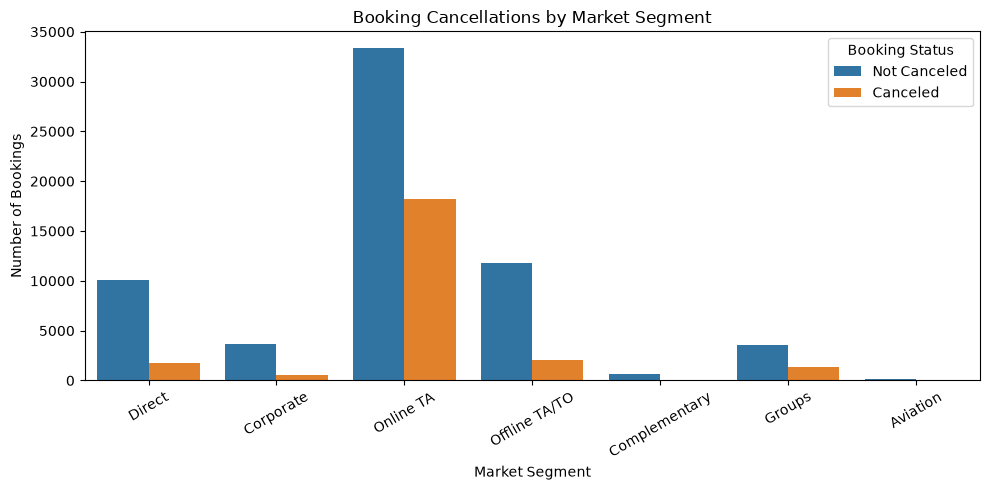

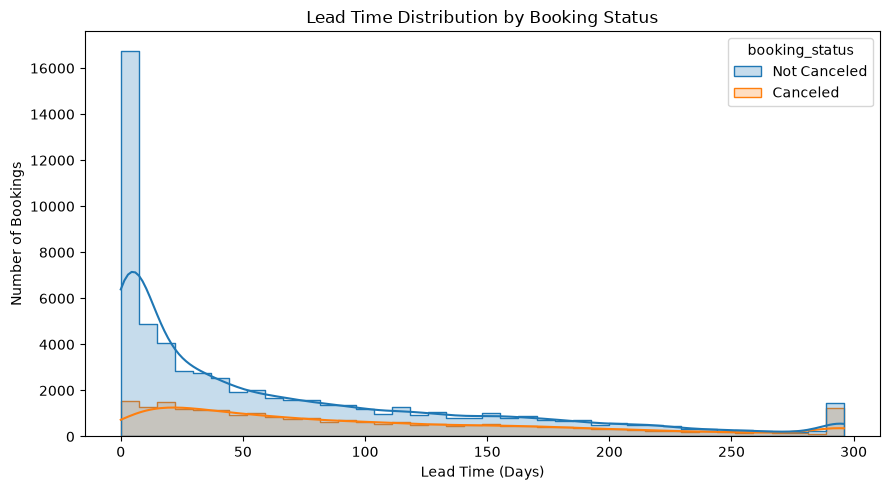

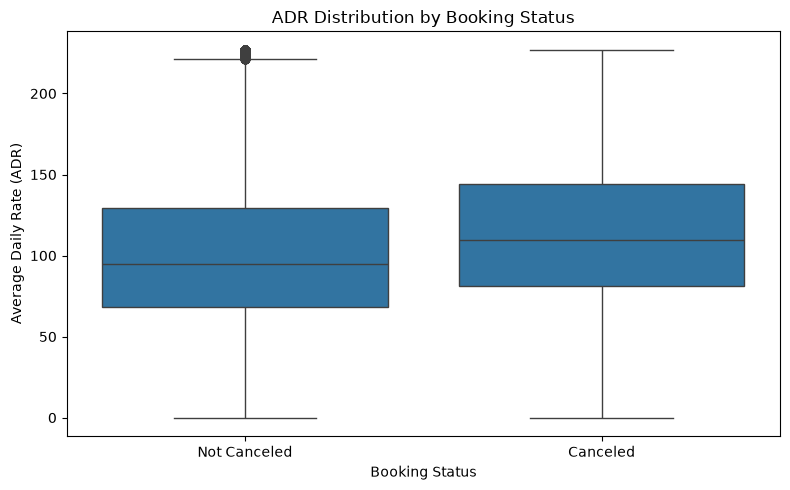

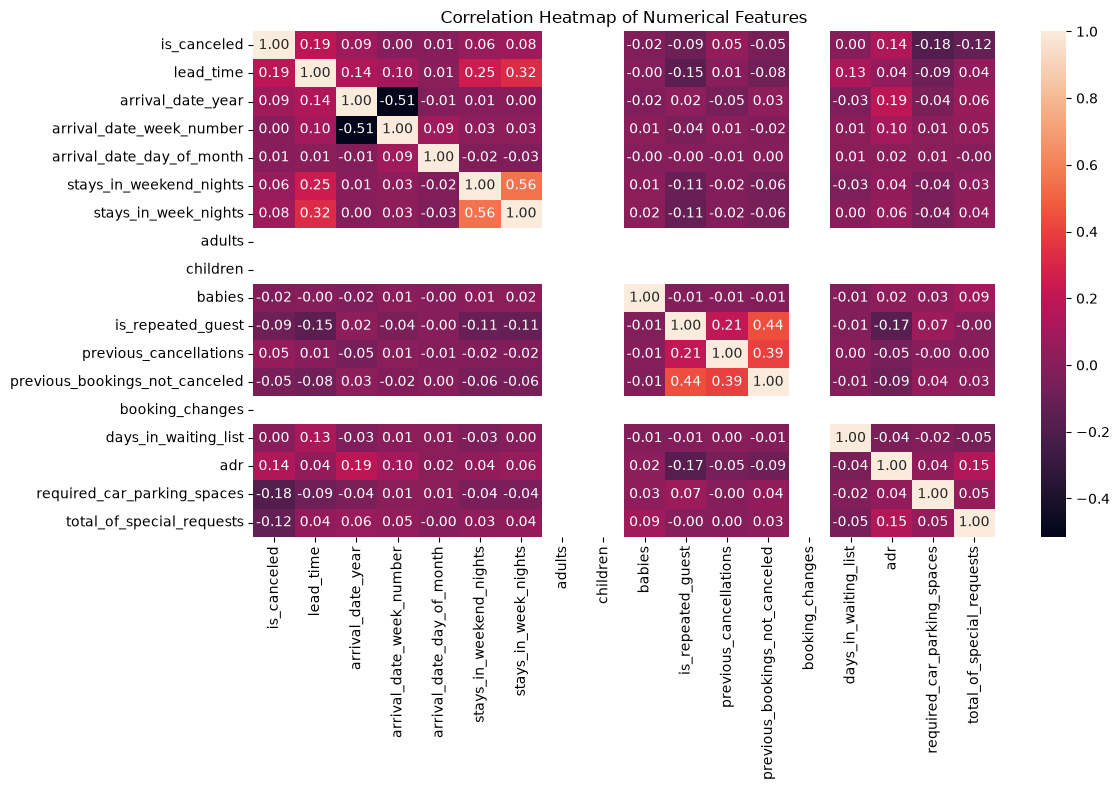

In [15]:
# =========================================================
# VISUALIZATION 1
# Overall Booking Cancellation Distribution
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="booking_status"
)

plt.title("Overall Booking Cancellation Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()


# =========================================================
# VISUALIZATION 2
# Booking Cancellations by Hotel Type
# =========================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="hotel",
    hue="booking_status"
)

plt.title("Booking Cancellations by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.legend(title="Booking Status")

plt.tight_layout()
plt.show()


# =========================================================
# VISUALIZATION 3
# Booking Cancellations by Market Segment
# =========================================================

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_clean,
    x="market_segment",
    hue="booking_status"
)

plt.title("Booking Cancellations by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=30)

plt.legend(title="Booking Status")

plt.tight_layout()
plt.show()


# =========================================================
# VISUALIZATION 4
# Lead Time Distribution by Booking Status
# =========================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="lead_time",
    hue="booking_status",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Lead Time Distribution by Booking Status")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()


# =========================================================
# VISUALIZATION 5
# ADR Distribution by Booking Status
# =========================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="booking_status",
    y="adr"
)

plt.title("ADR Distribution by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Daily Rate (ADR)")

plt.tight_layout()
plt.show()


# =========================================================
# VISUALIZATION 6
# Correlation Heatmap
# =========================================================

plt.figure(figsize=(12, 8))

numeric_df = df_clean.select_dtypes(
    include="number"
)

correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [16]:
# 1. Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 2. (80% Train , 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ◆ awel model (Logistic Regression) --->
log_model = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# prediction
log_preds = log_model.predict(X_test_scaled)

print("=== 1. Logistic Regression ===")
print(classification_report(y_test, log_preds))

=== 1. Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      0.92      0.86     12798
           1       0.66      0.43      0.52      4681

    accuracy                           0.79     17479
   macro avg       0.74      0.67      0.69     17479
weighted avg       0.77      0.79      0.77     17479



In [17]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

# predicition
tree_preds = tree_model.predict(X_test)

print("=== 2. Decision Tree Classifier ===")
print(classification_report(y_test, tree_preds))

=== 2. Decision Tree Classifier ===
              precision    recall  f1-score   support

           0       0.86      0.89      0.88     12798
           1       0.67      0.61      0.64      4681

    accuracy                           0.82     17479
   macro avg       0.77      0.75      0.76     17479
weighted avg       0.81      0.82      0.81     17479



## KNN and SVM Models

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### KNN

In [12]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn) * 100, "%")
print("Precision:", precision_score(y_test, y_pred_knn) * 100, "%")
print("Recall:", recall_score(y_test, y_pred_knn) * 100, "%")
print("F1 Score:", f1_score(y_test, y_pred_knn) * 100, "%")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))


=== KNN ===
Accuracy: 79.009096630242 %
Precision: 62.96550148503541 %
Recall: 57.368859283930064 %
F1 Score: 60.03703300294085 %
Confusion Matrix:
[[11054  1621]
 [ 2048  2756]]


### SVM

In [13]:
svm = LinearSVC(
    C=1,
    class_weight={0: 1, 1: 1.6},
    max_iter=5000,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm) * 100, "%")
print("Precision:", precision_score(y_test, y_pred_svm) * 100, "%")
print("Recall:", recall_score(y_test, y_pred_svm) * 100, "%")
print("F1 Score:", f1_score(y_test, y_pred_svm) * 100, "%")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

=== SVM ===
Accuracy: 77.08678986212027 %
Precision: 57.91245791245792 %
Recall: 60.865945045795165 %
F1 Score: 59.35248147772252 %
Confusion Matrix:
[[10550  2125]
 [ 1880  2924]]
